In [1]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml

from utils import *

In [2]:
# optical tweezers data

files = ['/Users/ursic/Downloads/opticaltweezers_intg1.csv', '/Users/ursic/Downloads/opticaltweezers_intg2.csv', '/Users/ursic/Downloads/opticaltweezers_metg1.csv', '/Users/ursic/Downloads/opticaltweezers_metg2.csv']


measurements = ['Int G_1', 'Int G_2', 'Met G_1', 'Met G_2']

df_OT_all = pd.DataFrame()
for (measurement, file) in zip(measurements, files):
    df_OT = pd.read_csv(file, names=[f'Rep {i}' for i in range(len(pd.read_csv(file, nrows=1).columns))])
    df_OT['Measurement'] = measurement

    for rep in range(len(pd.read_csv(file, nrows=1).columns)):
        for i in range(len(df_OT)):
            line = df_OT[f'Rep {rep}'].values[i].replace('{', '').replace('}', '').split(', ')
            df_OT.loc[i, 'freq [Hz]'] = float(line[0])
            df_OT.loc[i, f'Rep {rep}'] = float(line[1])
    
    df_OT_all = pd.concat([df_OT_all, df_OT], ignore_index=True)

df_OT_all.to_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/elastic_and_viscous_moduli_OT_all.csv')
df_OT_all.head()


,Rep 0,Rep 1,Rep 2,Rep 3,Rep 4,Rep 5,Rep 6,Rep 7,Rep 8,Rep 9,Rep 10,Rep 11,Rep 12,Measurement,freq [Hz]
0,1.391158,0.912267,0.959591,0.266865,0.971147,0.229768,1.525496,0.512431,0.642814,0.42949,1.171444,0.622651,1.330943,Int G_1,0.5
1,2.33911,0.532764,0.654931,0.541523,1.444879,0.731844,1.678443,0.971404,0.3966,0.6347,2.452058,0.78981,1.360988,Int G_1,1.0
2,1.74625,1.80046,1.479992,1.042903,2.550393,0.71302,1.828755,0.777175,0.894055,0.853994,3.271821,1.694538,1.2677,Int G_1,2.0
3,1.979198,1.91481,2.087282,1.75425,2.641923,1.405469,2.352281,0.840213,1.205819,0.928861,6.570719,1.28113,2.477495,Int G_1,4.0
4,3.305024,4.308892,2.685079,2.132748,4.906074,1.353849,2.913643,1.944911,1.385114,1.539713,8.69267,1.478335,3.72936,Int G_1,8.0


In [3]:
for i in range(len(df_OT_all)):
    df_OT_all.loc[i, 'avg'] = np.average([df_OT_all.loc[i, f'Rep {j}'] for j in range(12)])
    df_OT_all.loc[i, 'std'] = np.std([df_OT_all.loc[i, f'Rep {j}'] for j in range(12)])/12

In [4]:
def phenom_curve(t, a, b, c, d):
    return a*t + b + c * np.exp((-d*t))

In [5]:
config = yaml.safe_load(open('/Users/ursic/PhD/Projects/1_DataAnalysis_zebrafish/beads_in_zebrafish/magnetic_tweezers_SD/config.yml'))

filepath_measurements_info = config['filepath_measurements_info']
dir_plots = os.path.join(config['dir_parent'], '3_plots')  # Folder for saving plots
dir_analysis = os.path.join(config['dir_parent'], '2_analysis')  # Folder for saving analysis results
recalculate = config['recalculate']  # Whether to recalculate measurements if they already exist
pix_size = config['pix_size'] 
dt = config['dt']  # Time step in seconds

force_ranges = config['force_ranges']  # Force ranges for averaging curves
subtract_backgroung = config['subtract_background']  # Whether to subtract background from displacement
mt_codes = config['mt_codes']
conditions = config['conditions']

displacement_column = 'CORRECTED DISPLACEMENT [um]' if subtract_backgroung else 'DISPLACEMENT [um]'  # Use the 

In [6]:
# Convert the creep responce to J(t)=6 π R x(t)/f(t),

D = 2.8 # um # Bead diameter
R = D/2

min_freq = 1/4.5
max_freq = 1/0.5

subtr_bck_label = 'subtr_bck' if subtract_backgroung else 'no_subtr_bck'

df_creep_all = pd.read_csv(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/averaged_curves_per_embryo/averaged_curves_{subtr_bck_label}.csv')



df_converted_data = pd.DataFrame(columns=['freq [Hz]'])

fig = plt.figure(figsize=(8, 6), dpi=300)
for embryo in df_creep_all['EMBRYO'].unique():
    df_creep = df_creep_all[df_creep_all['EMBRYO']==embryo]
    for (color_palette, mt_status) in zip([sns.color_palette('tab10'), sns.color_palette('dark')], ['y', 'n']):

        if len(df_creep[df_creep['MT_STATUS']==mt_status]) == 0:
            continue
           
        t = df_creep.loc[(df_creep['MT_STATUS']==mt_status)&(df_creep['MAGNET_STATUS']>0.9), 'NORMALIZED_TIME'].values
        x = df_creep.loc[(df_creep['MT_STATUS']==mt_status)&(df_creep['MAGNET_STATUS']>0.9), displacement_column].values
        f = df_creep.loc[(df_creep['MT_STATUS']==mt_status)&(df_creep['MAGNET_STATUS']>0.9), 'FORCE [pN]'].values
        J = 6 * np.pi * R * x / f

        # Get G*

        g = lambda omega, eta, J0: complex(0, omega*J0) + (1 - np.exp(complex(0, -omega*t[1])))*(J[1]-J0)/t[1] + 1/eta * np.exp(complex(0, -omega*t[-1])) + np.sum([ (J[i]-J[i-1]) / (t[i]-t[i-1]) * (np.exp(complex(0, -omega*t[i-1]))-np.exp(complex(0, -omega*t[i]))) for i in range(2, len(t))])

        omega_values = np.linspace(min_freq, max_freq, 1000)

        try: 
            popt, pcov = curve_fit(phenom_curve, t, J, p0=[0, 1, -1, 1])
            J0 = max(0, popt[1] + popt[2])
            eta = 1/popt[0]
    
        except:
            print('One failed', embryo)
            J0 = 0
            eta = np.average(t[-3:-1] / (6 * np.pi * R * x / f)[-3:-1])
        
        print(eta, max(J0, 0))

        for omega in omega_values:
            new_row = {'freq [Hz]': omega, 
                        'G_1': (complex(0, 1)*omega/g(omega, eta, J0)).real, 
                        'G_2': (complex(0, 1)*omega/g(omega, eta, J0)).imag, 
                        'MT_STATUS': mt_status, 
                        'EMBRYO': embryo,
                        'COUNT': df_creep['COUNT'].values[0]}
            df_converted_data = pd.concat([df_converted_data, pd.DataFrame(new_row, index=[0])], ignore_index=True)

df_converted_data.to_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/elastic_and_viscous_moduli_MgTw_all.csv')

6.1520367485174665 0.008273862249517983


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_7325/2339146043.py:55: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_converted_data = pd.concat([df_converted_data, pd.DataFrame(new_row, index=[0])], ignore_index=True)


3.2502982509055673 0.010246380293865487
4.388128673988716 0.03059038217953014
4.562297192589275 0.0031264740563051174
4.782721419710484 0.002281730672952953
2.062766547746612 0.006386919674686742
1.8860925032813969 0
7.458948631141012 0
1.8264237277994646 0.013572137212803259
1.3113139316103464 0
7.6479867326658075 0.001826380482197576
2.1225139553669305 0
0.560562388351098 0.011424440919145074
3.06182738096032 0.005290908497176061
One failed 20240705s03p01
0.32941900139975766 0
5.964304908158693 0.0013796635839075644


<Figure size 2400x1800 with 0 Axes>

In [7]:
df_converted_data.to_csv(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/averaged_curves_per_embryo/converted_averaged_curves_{subtr_bck_label}.csv')
df_converted_data['EMBRYO'].unique()

array(['20240523s01p01', '20240523s02p01', '20240614s02p02',
       '20240621s01p01', '20240621s02p01', '20240621s02p02',
       '20240703s03p01', '20240705s01p01', '20240705s02p01',
       '20240705s03p01', '20240711s01p01'], dtype=object)

In [8]:
df_grouped_mean = df_converted_data[['freq [Hz]', 'G_1', 'G_2', 'MT_STATUS']].groupby(['freq [Hz]', 'MT_STATUS']).mean().reset_index()
df_grouped_std = df_converted_data[['freq [Hz]', 'G_1', 'G_2', 'MT_STATUS']].groupby(['freq [Hz]', 'MT_STATUS']).sem().reset_index()

df_grouped_mean.to_csv(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/elastic_and_viscous_moduli_magtw_converted_{subtr_bck_label}.csv')
df_grouped_mean.head()

,freq [Hz],MT_STATUS,G_1,G_2
0,0.222222,n,0.166235,0.238841
1,0.222222,y,0.382119,0.831983
2,0.224002,n,0.167093,0.239657
3,0.224002,y,0.386450,0.835851
4,0.225781,n,0.167945,0.240470


In [9]:
# bootstrapping 

df_bootstrapped_res = dict({})

for (param, mt_status) in zip(['G_1', 'G_2', 'G_1', 'G_2'], ['y', 'y', 'n', 'n']):
    data_groups = []
    df = df_converted_data.loc[df_converted_data['MT_STATUS']==mt_status]
    weights = []
    for embryo in df['EMBRYO'].unique():
        data_groups.append(df.loc[df['EMBRYO']==embryo, param])
        weights.append(df.loc[df['EMBRYO']==embryo, 'COUNT'].values[0])
    mean, ci = weighted_bootstrap(np.array(data_groups), weights=weights)

32.38005444024863 56.49291957155273 190.2753701775723


/var/folders/c1/95zwm3_14_j1wp412s49dvlr0000gp/T/ipykernel_7325/3341143188.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_converted_data_jeff = pd.concat([df_converted_data_jeff, pd.DataFrame(new_row, index=[0])], ignore_index=True)


21.283621808811876 26.693995415267075 41.99154361801042


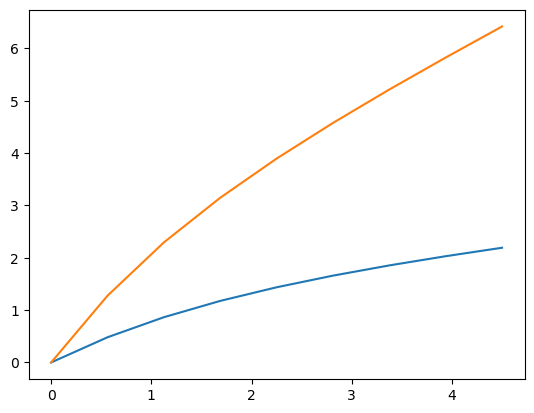

In [10]:
# Jeffrey's discretization converted to g' g''

df_jeff_data = pd.read_csv(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/results_material_properies_avg_curves_stats_{subtr_bck_label}.csv')
df_converted_data_jeff = pd.DataFrame(columns=['freq [Hz]'])

mt_codes = ['y', 'n']
for mt_status in mt_codes:

    k =  df_jeff_data.loc[(df_jeff_data['parameter']=='k')&(df_jeff_data['MT_STATUS']==mt_status), 'weighted_average'].values[0]
    eta_1 =  df_jeff_data.loc[(df_jeff_data['parameter']=='eta_1')&(df_jeff_data['MT_STATUS']==mt_status), 'weighted_average'].values[0]
    eta_2 =  df_jeff_data.loc[(df_jeff_data['parameter']=='eta_2')&(df_jeff_data['MT_STATUS']==mt_status), 'weighted_average'].values[0]

    print(k, eta_1, eta_2)

    t_1 = 4.5
    N_points = 9
    f_jeff = 42
    t_jeff = np.linspace(0, t_1, N_points)
    x_jeff = jeff_full(t_jeff, k, eta_1, eta_2, F_0=f_jeff, t_1=t_1)

    plt.plot(t_jeff, x_jeff)

    # Convert the creep responce to J(t)=6 π R x(t)/f(t),
    D = 2.8 # um # Bead diameter
    R = D/2
    min_freq = 1/t_1
    max_freq = 2

    J_jeff =  6 * np.pi * R * np.array(x_jeff) / f_jeff

    # Get G*

    g = lambda omega, eta, J0: complex(0, omega*J0) + (1 - np.exp(complex(0, -omega*t_jeff[1])))*(J_jeff[1]-J0)/t_jeff[1] + 1/eta * np.exp(complex(0, -omega*t_jeff[-1])) + np.sum([ (J_jeff[i]-J_jeff[i-1]) / (t_jeff[i]-t_jeff[i-1]) * (np.exp(complex(0, -omega*t_jeff[i-1]))-np.exp(complex(0, -omega*t_jeff[i]))) for i in range(2, len(t_jeff))])

    omega_values = np.linspace(min_freq, max_freq, 1000)

    try: 
        popt, pcov = curve_fit(phenom_curve, t_jeff, J_jeff, p0=[0, 1, -1, 1])
        J0 = max(0, popt[1] + popt[2])
        eta = 1/popt[0]

    except:
        print('One failed', embryo)
        J0 = 0
        eta = eta_2


    for omega in omega_values:
        new_row = {'freq [Hz]': omega, 
                    'G_1': (complex(0, 1)*omega/g(omega, eta, J0)).real, 
                    'G_2': (complex(0, 1)*omega/g(omega, eta, J0)).imag,  
                    'MT_STATUS': mt_status
                    }
        df_converted_data_jeff = pd.concat([df_converted_data_jeff, pd.DataFrame(new_row, index=[0])], ignore_index=True)

plt.show()

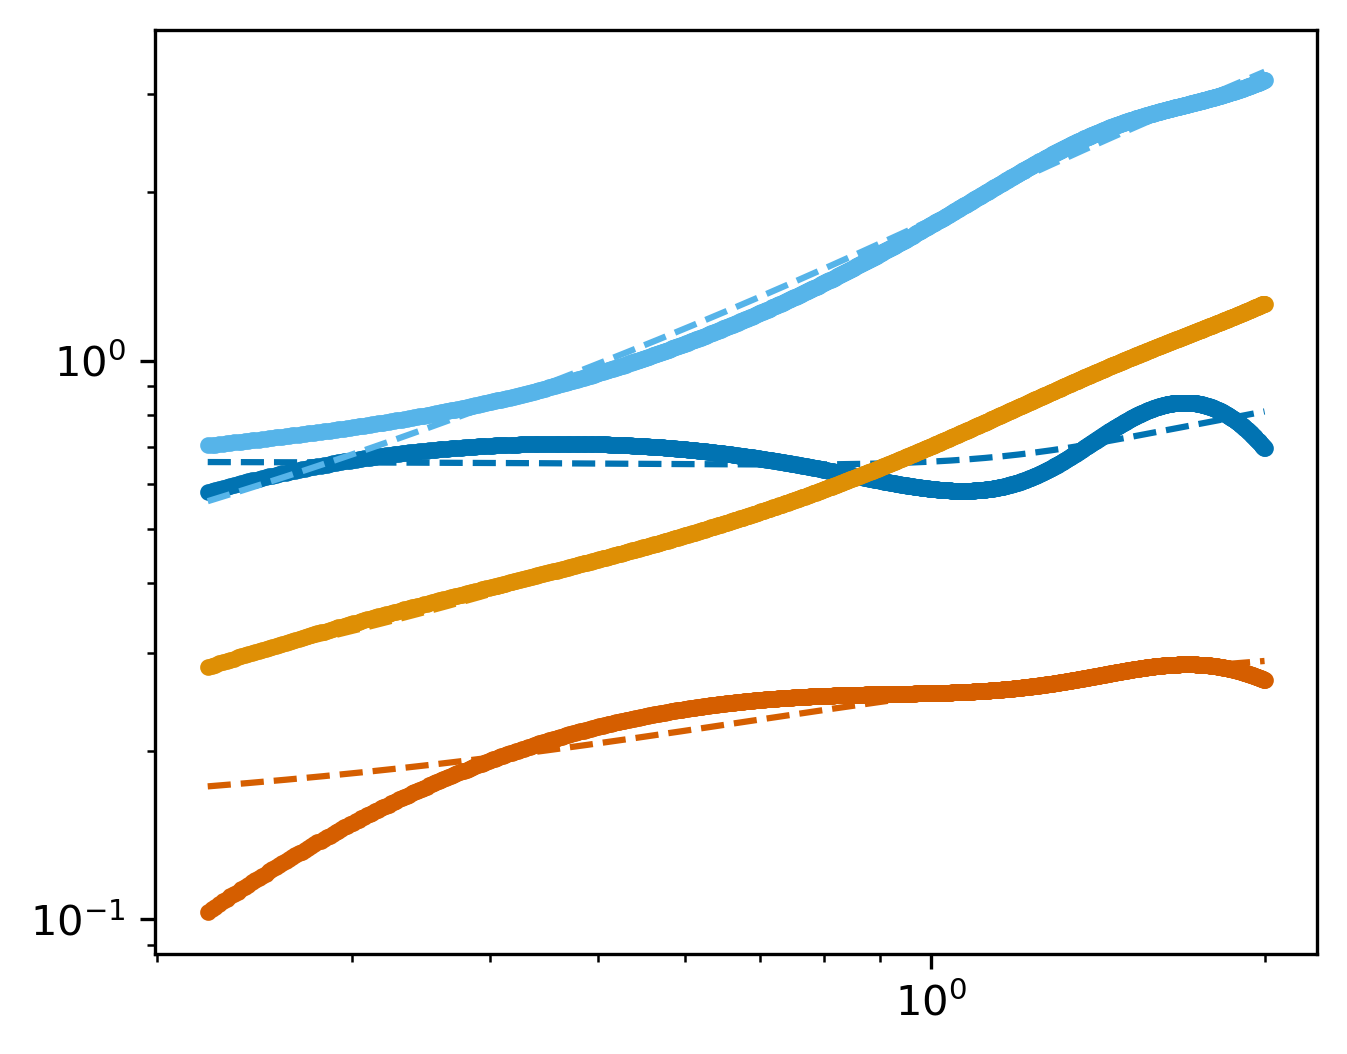

In [11]:
from scipy.interpolate import make_smoothing_spline
fig = plt.figure(figsize=(5, 4), dpi=300)

colors = [sns.color_palette('colorblind')[0], sns.color_palette('colorblind')[9], sns.color_palette('colorblind')[3], sns.color_palette('colorblind')[1]]

for (color, param, mt_status, label) in zip (colors, ['G_1', 'G_2', 'G_1', 'G_2'], ['y', 'y', 'n', 'n'], ['G\' Interphase', 'G\'\' Interphase', 'G\' M-phase', 'G\'\' M-phase']): 
    y = make_smoothing_spline(df_converted_data_jeff.loc[df_converted_data_jeff['MT_STATUS']==mt_status, 'freq [Hz]'], df_converted_data_jeff.loc[df_converted_data_jeff['MT_STATUS']==mt_status, param].values, lam=10)
    
    plt.plot(df_converted_data_jeff.loc[(df_converted_data_jeff['MT_STATUS']==mt_status), 'freq [Hz]'], 
             y(df_converted_data_jeff.loc[(df_converted_data_jeff['MT_STATUS']==mt_status), 'freq [Hz]']), '--', color=color)
    
    plt.plot(df_converted_data_jeff.loc[(df_converted_data_jeff['MT_STATUS']==mt_status), 'freq [Hz]'], 
             df_converted_data_jeff.loc[(df_converted_data_jeff['MT_STATUS']==mt_status), param], '.', color=color)

plt.xscale('log')
plt.yscale('log')
plt.show()

[5.000e-01 1.000e+00 2.000e+00 4.000e+00 8.000e+00 1.600e+01 3.200e+01
 6.400e+01 1.280e+02 2.560e+02 5.120e+02 1.028e+03 2.048e+03]


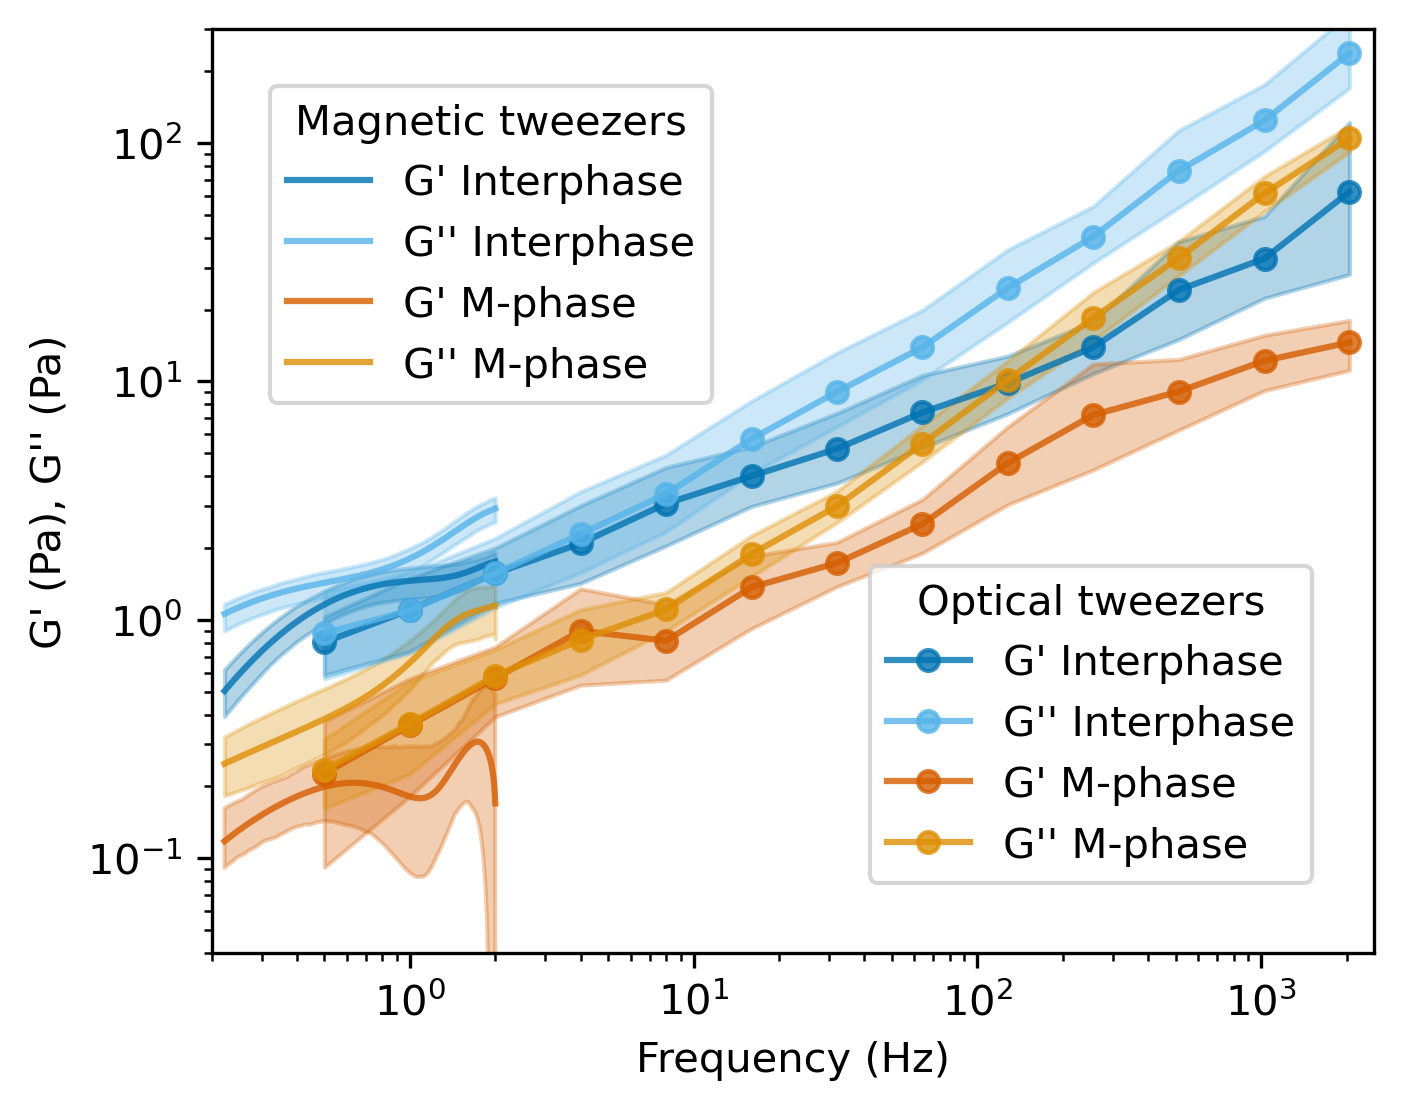

In [12]:
fig = plt.figure(figsize=(5, 4), dpi=300)

colors = [sns.color_palette('colorblind')[0], sns.color_palette('colorblind')[9], sns.color_palette('colorblind')[3], sns.color_palette('colorblind')[1]]



for (color, param, mt_status, label) in zip (colors, ['G_1', 'G_2', 'G_1', 'G_2'], ['y', 'y', 'n', 'n'], ['G\' Interphase', 'G\'\' Interphase', 'G\' M-phase', 'G\'\' M-phase']): 
    data_groups = []
    df = df_converted_data.loc[df_converted_data['MT_STATUS']==mt_status]
    weights = []
    for embryo in df['EMBRYO'].unique():
        data_groups.append(df.loc[df['EMBRYO']==embryo, param])
        weights.append(df.loc[df['EMBRYO']==embryo, 'COUNT'].values[0])

    mean, ci = weighted_bootstrap(np.array(data_groups), weights=weights)

    # y = make_smoothing_spline(df_converted_data_jeff.loc[df_converted_data_jeff['MT_STATUS']==mt_status, 'freq [Hz]'], df_converted_data_jeff.loc[df_converted_data_jeff['MT_STATUS']==mt_status, param].values, lam=10)
    
    
    # plt.plot(df_converted_data_jeff.loc[(df_converted_data_jeff['MT_STATUS']==mt_status), 'freq [Hz]'], 
    #          df_converted_data_jeff.loc[df_converted_data_jeff['MT_STATUS']==mt_status, param].values, '--', color=color)

    plt.plot(df_grouped_mean.loc[df_grouped_mean['MT_STATUS']==mt_status, 'freq [Hz]'], mean, '-', color=color, alpha=0.8, label=label)
    plt.fill_between(df_grouped_mean.loc[df_grouped_mean['MT_STATUS']==mt_status, 'freq [Hz]'],
                    ci[0], ci[1], color = color, alpha = 0.3)
    

    
fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.85), title='Magnetic tweezers')

handles = []
df_OT_all = df_OT_all[df_OT_all['freq [Hz]']<2500]
df_OT_mean = pd.DataFrame(columns=['G_1', 'G_2', 'freq [Hz]', 'MT_STATUS'])
df_OT_mean['freq [Hz]'] = df_OT_all['freq [Hz]'].unique()
print(df_OT_all['freq [Hz]'].unique())
for (color, measurement, label) in zip(colors, measurements, ['G\' Interphase', 'G\'\' Interphase', 'G\' M-phase', 'G\'\' M-phase']):
    
    df_OT_measurement = df_OT_all[(df_OT_all['Measurement']==measurement)]

    data_groups = np.array([df_OT_all.loc[df_OT_all['Measurement']==measurement, f'Rep {j}'] for j in range(12)])
    
    mean, ci = weighted_bootstrap(data_groups)

    handle, = plt.plot(df_OT_measurement['freq [Hz]'], mean, '.-', markersize=10, color=color, alpha=0.8, label=label)
    handles.append(handle)

    plt.fill_between(df_OT_measurement['freq [Hz]'], ci[0].astype(float), ci[1].astype(float), color = color, alpha = 0.3)

    df_OT_mean[label] = mean

fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.55, 0.45), title='Optical tweezers')



plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)', fontsize=10)
plt.ylabel('G\' (Pa), G\'\' (Pa)', fontsize=10)
plt.ylim(0.04, 300)
plt.xlim(0.2, 2500)
# plt.show()
plt.savefig(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/elastic_and_viscous_moduli_magtw_OT_{subtr_bck_label}.svg', format='svg')
plt.savefig(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/elastic_and_viscous_moduli_magtw_OT_{subtr_bck_label}.pdf')

In [13]:
df_OT_mean.to_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/elastic_and_viscous_moduli_OT_mean.csv')
df_OT_mean.head()

,G_1,G_2,freq [Hz],MT_STATUS,G' Interphase,G'' Interphase,G' M-phase,G'' M-phase
0,NaN,NaN,0.5,NaN,0.805178,0.877856,0.22649,0.234858
1,NaN,NaN,1.0,NaN,1.100178,1.095205,0.360228,0.366309
2,NaN,NaN,2.0,NaN,1.563124,1.563595,0.568745,0.581802
3,NaN,NaN,4.0,NaN,2.091203,2.290149,0.898796,0.8237
4,NaN,NaN,8.0,NaN,3.070268,3.368302,0.81571,1.104471


In [14]:
df_OT_all.head(5)

,Rep 0,Rep 1,Rep 2,Rep 3,Rep 4,Rep 5,Rep 6,Rep 7,Rep 8,Rep 9,Rep 10,Rep 11,Rep 12,Measurement,freq [Hz],avg,std
0,1.391158,0.912267,0.959591,0.266865,0.971147,0.229768,1.525496,0.512431,0.642814,0.42949,1.171444,0.622651,1.330943,Int G_1,0.5,0.802927,0.033735
1,2.33911,0.532764,0.654931,0.541523,1.444879,0.731844,1.678443,0.971404,0.3966,0.6347,2.452058,0.78981,1.360988,Int G_1,1.0,1.097339,0.056969
2,1.74625,1.80046,1.479992,1.042903,2.550393,0.71302,1.828755,0.777175,0.894055,0.853994,3.271821,1.694538,1.2677,Int G_1,2.0,1.554446,0.061987
3,1.979198,1.91481,2.087282,1.75425,2.641923,1.405469,2.352281,0.840213,1.205819,0.928861,6.570719,1.28113,2.477495,Int G_1,4.0,2.080163,0.121287
4,3.305024,4.308892,2.685079,2.132748,4.906074,1.353849,2.913643,1.944911,1.385114,1.539713,8.69267,1.478335,3.72936,Int G_1,8.0,3.053838,0.169334


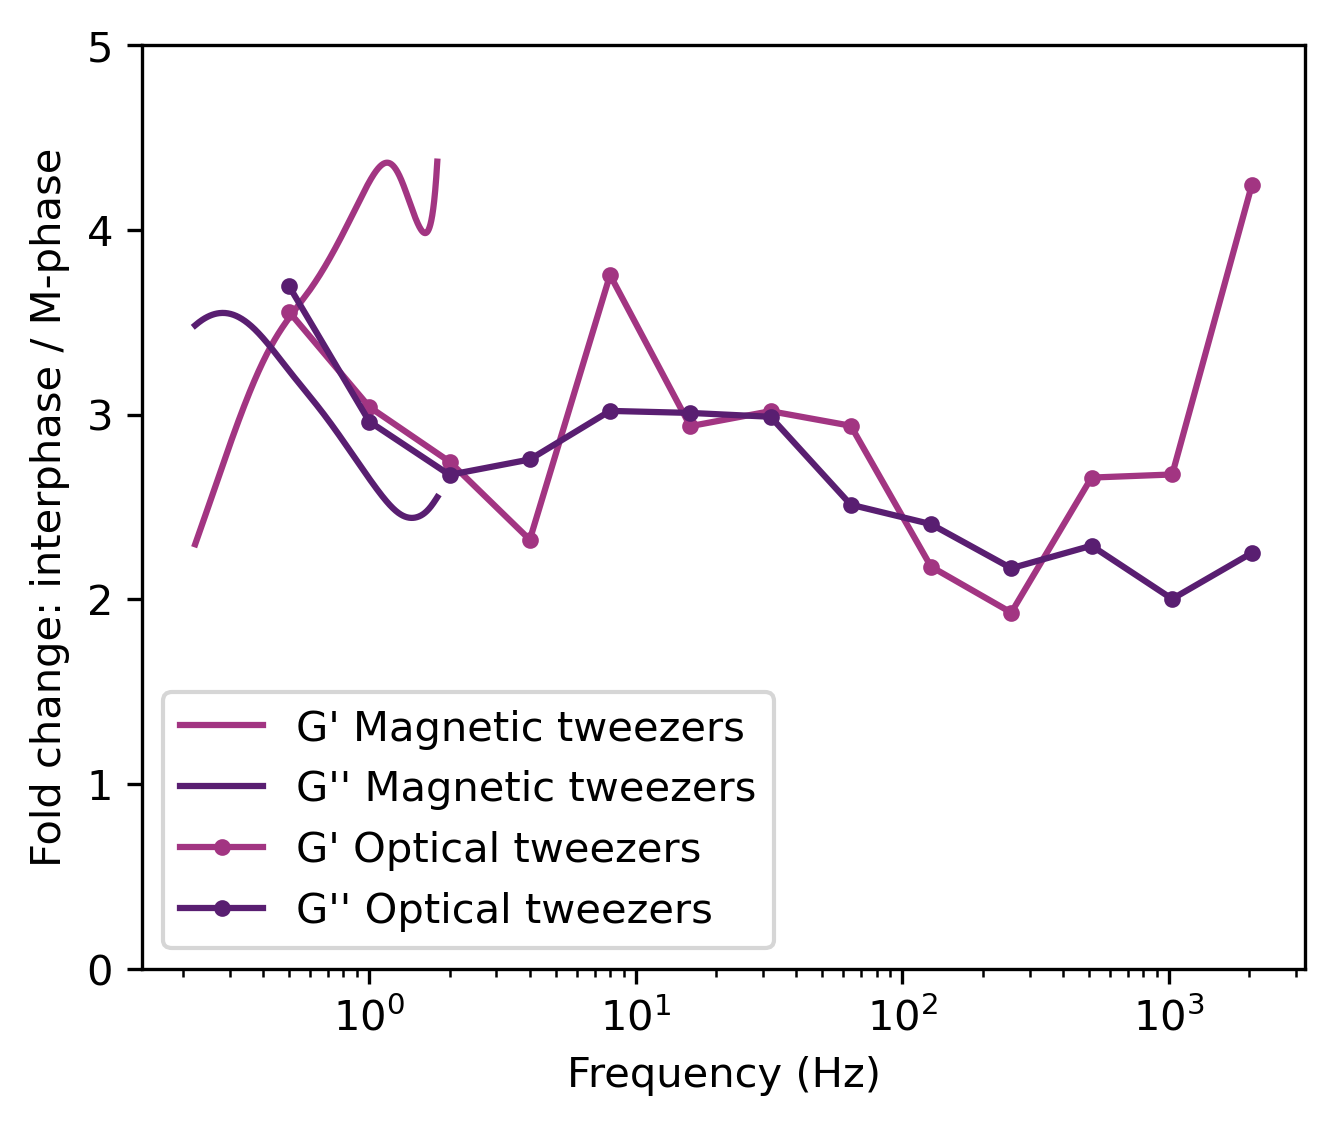

In [15]:
colors_ratio = [sns.color_palette('dark')[6], sns.color_palette('dark')[4]]
plt.figure(figsize=(5, 4), dpi=300)
for (color, param, label) in zip(colors_ratio, ['G_1', 'G_2'], ['G\' Magnetic tweezers', 'G\'\' Magnetic tweezers']): 
    df_grouped_mean = df_grouped_mean[df_grouped_mean['freq [Hz]']<1.8]

    plt.plot(df_grouped_mean.loc[df_grouped_mean['MT_STATUS']==mt_status, 'freq [Hz]'], np.divide(df_grouped_mean.loc[df_grouped_mean['MT_STATUS']=='y',param].values, df_grouped_mean.loc[df_grouped_mean['MT_STATUS']=='n',param].values), '-', color=color, label=label)

for (color, param, label) in zip(colors_ratio, ['G_1', 'G_2'], ['G\' Optical tweezers', 'G\'\' Optical tweezers']): 
    plt.plot(df_OT_all.loc[df_OT_all['Measurement']==f'Int {param}', 'freq [Hz]'], np.divide(df_OT_all.loc[df_OT_all['Measurement']==f'Int {param}', 'avg'].values.astype(float), df_OT_all.loc[df_OT_all['Measurement']==f'Met {param}', 'avg']), '.-', color=color, label=label)
    
plt.ylim(0, 5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fold change: interphase / M-phase')
plt.legend()
plt.xscale('log')
plt.savefig(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/elastic_and_viscous_moduli_magtw_OT_ratios_{subtr_bck_label}.svg', format='svg')
plt.show()